# (11) Retina+V1: ImageNet32

host: ```mach```, device: ```cuda:0```

**motivation:** <br>

ImageNet32

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_RetinaV1'))
from figures.convergence import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from main.config import Config


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: mach

In [3]:
cfg_layers = [
    CFG_CLASSES['gaus'](n_latents=64, beta_outer=128.0, latent_act='gompertz'),
    CFG_CLASSES['pois'](n_latents=256, beta_outer=64.0),
]
cfg = Config(
    dataset='ImageNet32',
    cfg_layers=cfg_layers,
    t_train=16,
    n_iters_warmup=32,
)

In [4]:
tr = Trainer(
    model=RetinaV1(cfg),
    cfg=ConfigTrain(chkpt_freq=1, eval_freq=1, epochs=20, lr=1e-4, grad_clip=2000),
    device=device,
)
tr.n_iters

128100

In [5]:
tr.model.print()

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|   RetinaV1  |  990.1 K   |
|     ———     |    ———     |
|  layers.g0  |  200.1 K   |
|  layers.p1  |  790.0 K   |
+-------------+------------+

In [6]:
tr.print()

ImageNet32_m(g0+gomp,p1)_t(32+16)_b(128,64)_k(64,256)
b200-ep20-lr(0.0001)_temp(0.01:0.5)_gr(2000)_(2025_04_15,21:04)

In [7]:
tr.train()

epoch # 20, avg loss: 701.697: 100%|███████| 20/20 [10:56:25<00:00, 1969.28s/it]


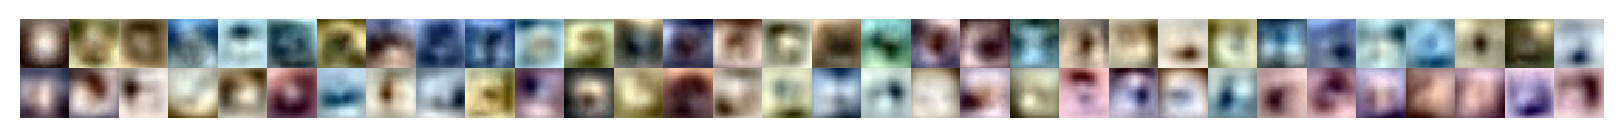

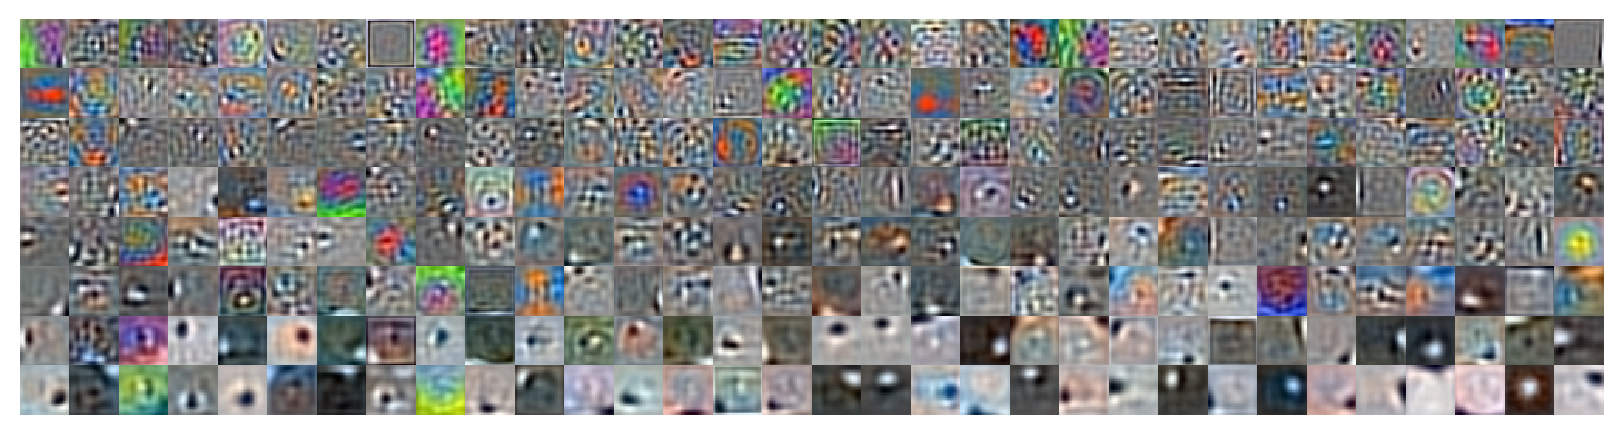

In [11]:
u0 = {
    k: tonp(layer.u_init[0].squeeze()) for
    k, layer in tr.model.layers.items()
}
for k, v in u0.items():
    kws = dict(
        order=np.argsort(v),
        nrows=8 if k == 'p1' else 2,
        # method='abs-max',
    )
    tr.model.show(k, **kws);

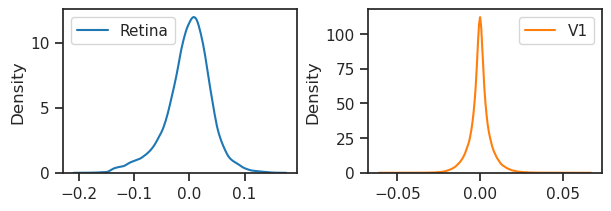

In [9]:
fig, axes = create_figure(1, 2)

sns.kdeplot(tonp(tr.model.layers['g0'].get_weight().ravel()), color='C0', label='Retina', ax=axes[0])
sns.kdeplot(tonp(tr.model.layers['p1'].get_weight().ravel()), color='C1', label='V1', ax=axes[1])

add_legend(axes)
plt.show()

In [18]:
%%time


items = ['mse', 'r2', 'u', 'samples']

t_total = 1000

r2 = {k: np_nans(t_total) for k in tr.model.layers}
mse = {k: np_nans(t_total) for k in tr.model.layers}

true = []
pred = collections.defaultdict(list)
error = collections.defaultdict(list)

state = collections.defaultdict(list)
samples = collections.defaultdict(list)

for x, *_ in tqdm(iter(tr.dl_vld)):
    feeder = tr.get_feeder(x)
    for t in range(t_total):
        tr.model.update_time(t)
        inpt = tr.to(feeder[t])
        output = tr.model.xtract_ftr(inpt, return_extras=items)
        for k, d in output.items():
            r2[k][t] = d['r2'].mean(0).item()
            mse[k][t] = d['mse'].mean(0).item()

        if (t + 1) == t_total:
            true.append(inpt.flatten(start_dim=1))
            for k, layer in tr.model.layers.items():
                pred[k].append(layer.conditional.loc)
                state[k].append(output[k]['u'])
                samples[k].append(output[k]['samples'])
            pred_error_retina = tr.model.layers['g0'].pred_error(
                x=inpt, weighted=False)
            error['g0'].append(pred_error_retina)
            error['p1'].append(tr.model.layers['p1'].pred_error(
                x=pred_error_retina, weighted=False))

del output
torch.cuda.empty_cache()
import gc
gc.collect()

true = torch.cat(true)
pred = {k: torch.cat(v) for k, v in pred.items()}
error = {k: torch.cat(v) for k, v in error.items()}
state = {k: torch.cat(v) for k, v in state.items()}
samples = {k: torch.cat(v) for k, v in samples.items()}

100%|█████████████████████████████████████████| 250/250 [25:44<00:00,  6.18s/it]


CPU times: user 25min 44s, sys: 1.28 s, total: 25min 45s
Wall time: 25min 44s


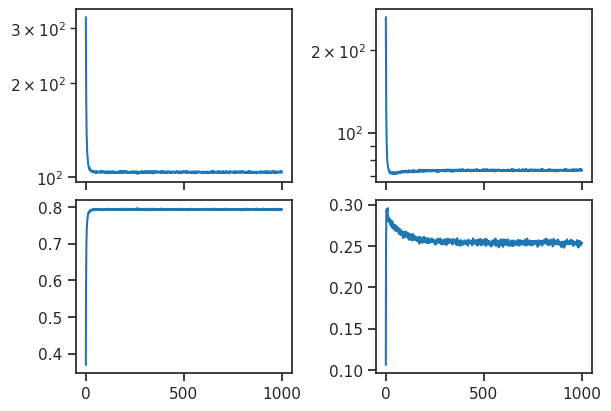

In [22]:
fig, axes = create_figure(2, 2, sharex='all')
axes[0, 0].plot(mse['g0'])
axes[0, 1].plot(mse['p1'])
axes[1, 0].plot(r2['g0'])
axes[1, 1].plot(r2['p1'])

axes[0, 0].set(yscale='log')
axes[0, 1].set(yscale='log')
# axes[-1, -1].set(xscale='log')
plt.show()

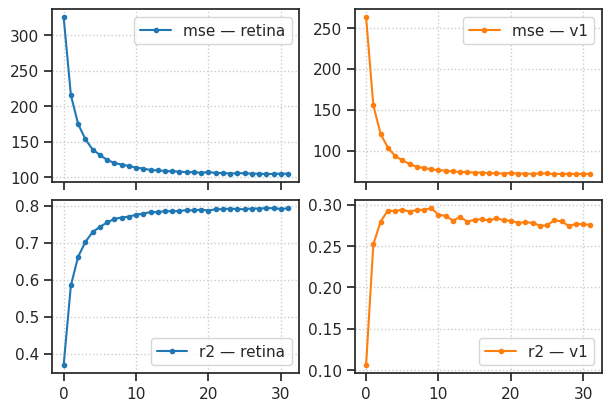

In [23]:
fig, axes = create_figure(2, 2, sharex='all')

intvl = range(32)

axes[0, 0].plot(mse['g0'][intvl], marker='.', label='mse — retina')
axes[0, 1].plot(mse['p1'][intvl], marker='.', color='C1', label='mse — v1')
axes[1, 0].plot(r2['g0'][intvl], marker='.', label='r2 — retina')
axes[1, 1].plot(r2['p1'][intvl], marker='.', color='C1', label='r2 — v1')

add_legend(axes)
add_grid(axes)
# axes[-1, -1].set(xscale='log')
plt.show()

In [25]:
# order: high contrast
var = tonp(torch.var(true, dim=1))
order = np.argsort(var)[::-1]

In [28]:
def _reshape_transpose(x):
    x = x.reshape(3, 32, 32)
    x = np.transpose(x, (1, 2, 0))
    x = (1 + x) / 2
    return x

def _plot_selected_samples(select_from=None, ncols=20, seed=0):
    rng = get_rng(seed)

    nrows = 6
    fig, axes = create_figure(nrows, ncols, (1 * ncols + 0.1, 1 * nrows), 'all', 'all')

    select_from = order[:200] if select_from is None else select_from
    selected_ids = rng.choice(select_from, size=ncols, replace=False)

    for i in range(ncols):
        idx = selected_ids[i]
        axes[0, i].imshow(_reshape_transpose(tonp(true[idx])))
        axes[1, i].imshow(_reshape_transpose(tonp(pred['g0'][idx])))
        axes[2, i].imshow(_reshape_transpose(tonp(error['g0'][idx])))
        # axes[3, i].imshow(tonp(whitened[idx]).reshape(16, 16), cmap='Greys_r')
        axes[4, i].imshow(_reshape_transpose(tonp(pred['p1'][idx])))
        axes[5, i].imshow(_reshape_transpose(tonp(error['p1'][idx])))

    axes[0, 0].set_ylabel('img', fontsize=15)
    axes[1, 0].set_ylabel('pred\n(retina)', fontsize=15)
    axes[2, 0].set_ylabel('error\n(retina)', fontsize=15)
    axes[3, 0].set_ylabel('whitened', fontsize=15)
    axes[4, 0].set_ylabel('pred\n(v1)', fontsize=15)
    axes[5, 0].set_ylabel('error\n(v1)', fontsize=15)

    remove_ticks(axes, False)
    plt.show()

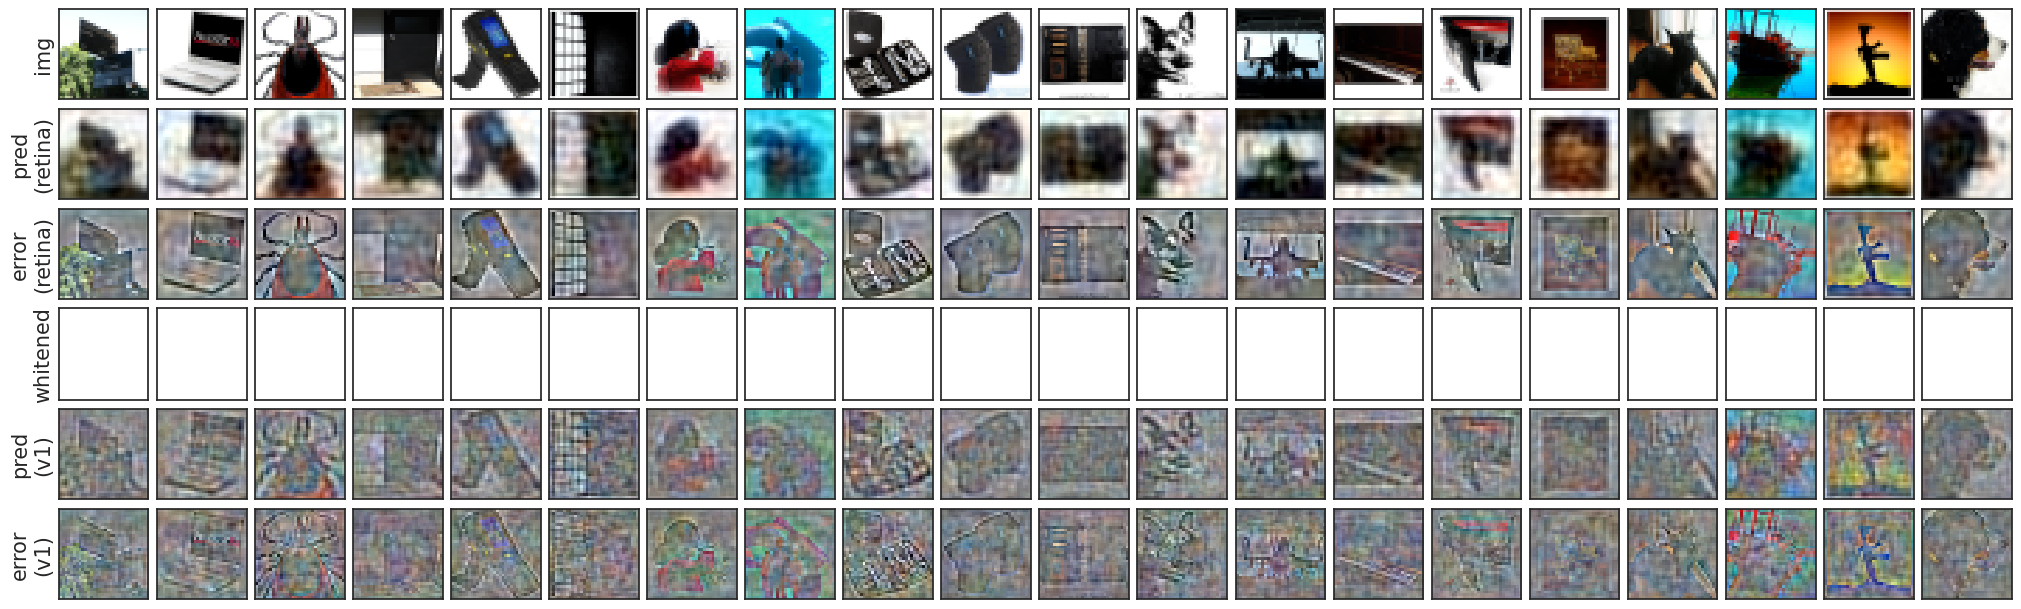

In [29]:
_plot_selected_samples()

In [30]:
life, pop, portions = sparse_score(samples['p1'], cutoff=0.001)
life.mean()

tensor(0.9996, device='cuda:0')

In [31]:
print(portions)

{
    '0': 56.0,
    '1': 8.9,
    '2': 7.3,
    '3': 6.0,
    '4': 4.8,
    '5': 3.8,
    '6': 3.0,
    '7': 2.3,
    '8': 1.8,
    '9': 1.4,
    '10': 1.1,
    '11': 0.8,
    '12': 0.6,
    '13': 0.5,
    '14': 0.4,
    '15': 0.3,
    '16': 0.2,
    '17': 0.2,
    '18': 0.1,
    '19': 0.1,
    '20+': 0.3
}